In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from finta import TA
import yfinance as yf

In [2]:
stock = ['MSFT']
df = yf.download(stock, '2017-01-01', '2021-01-01')

df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]
df.columns = [c.split('_')[0].lower() for c in df.columns]
df

[*********************100%***********************]  1 of 1 completed


,close,high,low,open,volume
Date,,,,,
2017-01-03,56.171108,56.404480,55.767193,56.359601,20694100
2017-01-04,55.919777,56.323693,55.758211,56.081343,21340000
2017-01-05,55.919777,56.242909,55.677428,55.821042,24876000
2017-01-06,56.404484,56.682738,55.686413,55.919785,19922900
2017-01-09,56.224964,56.619905,56.135207,56.332674,20382700
...,...,...,...,...,...
2020-12-24,213.250732,214.074058,211.766830,211.977449,10550600
2020-12-28,215.366501,216.390863,213.509231,214.878241,17933500
2020-12-29,214.591064,217.491848,214.045380,216.658954,17403200


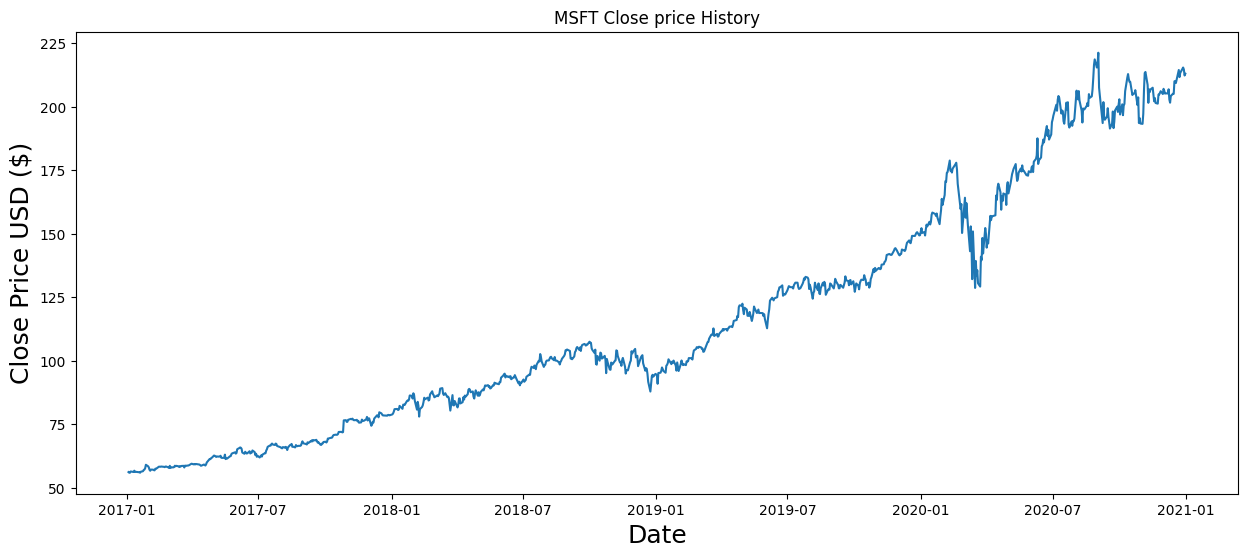

In [3]:
plt.figure(figsize=(15,6))
plt.title('MSFT Close price History')
plt.plot(df['close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [4]:
df.describe()

,close,high,low,open,volume
count,1007.000000,1007.000000,1007.000000,1007.000000,1.007000e+03
mean,116.535026,117.656807,115.280083,116.511078,2.907935e+07
std,46.243971,46.865803,45.569627,46.220315,1.355701e+07
min,55.919777,56.242909,55.605628,55.821042,7.425600e+06
25%,79.251179,80.104576,78.457425,79.214474,2.028265e+07
50%,102.621635,103.639335,101.407864,102.538289,2.539980e+07
75%,146.029129,147.535471,143.287668,144.278965,3.329715e+07
max,221.192108,222.347489,217.086244,218.919573,1.112421e+08


In [5]:
print(type(df))

<class 'pandas.DataFrame'>


In [6]:
df['SMA200'] = TA.SMA(df, 200)
df['RSI'] = TA.RSI(df)
df['ATR'] = TA.ATR(df)
df['BBWidth'] = TA.BBWIDTH(df)
df['Williams'] = TA.WILLIAMS(df)

df = df.iloc[200:, :]

In [7]:
df.tail(10)

,close,high,low,open,volume,SMA200,RSI,ATR,BBWidth,Williams
Date,,,,,,,,,,
2020-12-17,210.062790,211.470103,208.626758,210.493597,32515800,187.421506,59.818335,3.453314,0.046476,-12.478707
2020-12-18,209.268158,210.321254,206.807764,209.268158,63354900,187.700465,57.966657,3.404078,0.049241,-19.524746
2020-12-21,213.097595,214.447469,208.014044,208.272534,37181900,188.050578,63.784699,3.592130,0.056365,-9.469423
2020-12-22,214.390015,216.007946,212.389147,213.193321,22612200,188.358233,65.519348,3.617432,0.062941,-10.230002
2020-12-23,211.594543,214.026218,211.383924,213.595411,18699600,188.686535,58.942957,3.645468,0.065844,-27.905455
2020-12-24,213.250732,214.074058,211.766830,211.977449,10550600,189.092319,61.414038,3.672134,0.070323,-17.433557
2020-12-28,215.366501,216.390863,213.509231,214.878241,17933500,189.414783,64.364720,3.722054,0.077890,-6.323818
2020-12-29,214.591064,217.491848,214.045380,216.658954,17403200,189.844557,62.478946,3.690598,0.081774,-16.768061
2020-12-30,212.226410,216.007973,212.025374,215.625022,20272300,190.209549,56.995099,3.646834,0.083149,-30.437013


In [8]:
df['target'] = df.close.shift(-1)
df.dropna(inplace=True)
df.head()

,close,high,low,open,volume,SMA200,RSI,ATR,BBWidth,Williams,target
Date,,,,,,,,,,,
2017-10-18,70.861458,71.080587,70.642329,70.916238,13300700,62.681459,72.604222,0.632608,0.081428,-6.248952,71.135361
2017-10-19,71.135361,71.153619,70.624051,70.824922,15092800,62.757537,74.322534,0.626739,0.084517,-0.473855,71.957092
2017-10-20,71.957092,72.103183,71.418399,71.509702,22866400,62.837724,78.649178,0.649565,0.090517,-3.041898,71.975380
2017-10-23,71.975380,72.441028,71.911467,72.121464,20627200,62.915578,78.735055,0.642391,0.090489,-9.058497,72.002762
2017-10-24,72.002762,72.313194,71.637542,72.039284,17517200,62.994467,78.872082,0.624782,0.088069,-10.959017,71.792755


In [9]:
def train_test_split(data, perc):
    data = data.values
    n = int(len(data) *(1 - perc))
    return data[:n], data[n:]

In [10]:
train, test = train_test_split(df, 0.2)
train

array([[ 7.08614578e+01,  7.10805868e+01,  7.06423289e+01, ...,
         8.14283419e-02, -6.24895184e+00,  7.11353607e+01],
       [ 7.11353607e+01,  7.11536186e+01,  7.06240506e+01, ...,
         8.45171232e-02, -4.73854505e-01,  7.19570923e+01],
       [ 7.19570923e+01,  7.21031829e+01,  7.14183989e+01, ...,
         9.05174928e-02, -3.04189841e+00,  7.19753799e+01],
       ...,
       [ 1.74402863e+02,  1.75305271e+02,  1.73433954e+02, ...,
         1.18792762e-01, -5.15183342e+00,  1.75428741e+02],
       [ 1.75428741e+02,  1.75732719e+02,  1.74174872e+02, ...,
         1.16629694e-01, -1.69405966e+00,  1.77385559e+02],
       [ 1.77385559e+02,  1.78116977e+02,  1.73690423e+02, ...,
         1.15260091e-01, -4.24938899e+00,  1.73367432e+02]],
      shape=(644, 11))

In [11]:
X = train[:,:-1]
y = train[:,-1]
y

array([ 71.13536072,  71.95709229,  71.97537994,  72.00276184,
        71.79275513,  71.91144562,  76.52230835,  76.59536743,
        75.94711304,  75.94711304,  76.74146271,  76.82363129,
        77.12492371,  76.94232178,  77.20707703,  76.77797699,
        76.57711029,  76.63191223,  76.74146271,  76.14499664,
        76.34687042,  75.61276245,  75.73206329,  76.8240509 ,
        76.26430511,  76.40194702,  76.96170044,  77.8884964 ,
        76.47535706,  77.23695374,  77.31956482,  74.40149689,
        74.86947632,  75.96148682,  75.69533539,  77.22779846,
        78.20968628,  78.53083801,  78.31975555,  77.71414185,
        79.69623566,  79.26493835,  78.76023865,  78.47577667,
        78.45742798,  78.46661377,  78.36566925,  78.6501236 ,
        78.65931702,  78.49412537,  78.87036133,  79.23741913,
        79.93483734,  80.92584991,  81.008461  ,  80.95339203,
        80.5863266 ,  80.82492065,  82.2197113 ,  81.07268524,
        82.71524811,  82.67855072,  82.5867691 ,  84.06

In [12]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
params = {'max_depth': [3,6],
          'learning_rate': [0.05],
          'n_estimators': [700, 1000],
          'colsample_bytree': [0.3, 0.7]}

xgbr = XGBRegressor(random_state=20)
modl = GridSearchCV(estimator=xgbr,
                    param_grid=params,
                    scoring = 'neg_mean_squared_error',
                    verbose = 1)

modl.fit(X,y)
print("Best parameters:", modl.best_params_)
print("Lowest RMSE: ", (-modl.best_score_)**(1/2.0))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'colsample_bytree': 0.3, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000}
Lowest RMSE:  11.184154465145209


In [13]:
from xgboost import XGBRegressor
model = XGBRegressor(objective='reg:squarederror', n_estimators=750, colsample_bytree=0.7, learning_rate=0.05, max_depth=3, gamma=1)
model.fit(X,y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [14]:
test[0,:]

array([ 1.73367432e+02,  1.77670507e+02,  1.73167959e+02,  1.77442539e+02,
        3.20382000e+07,  1.45721258e+02,  5.86554040e+01,  4.18094832e+00,
        1.17198929e-01, -2.75938995e+01,  1.70745728e+02])

In [15]:
val = np.array(test[0, :-1]).reshape(1,-1)
pred = model.predict(val)
pred

array([172.29732], dtype=float32)

In [16]:
def xgb_predict(train, val):
    train = np.array(train)
    X, y = train[:, :-1], train[:,-1]
    model = XGBRegressor(objective='reg:squarederror', n_estimators=750, learning_rate=0.05, colsample_bytree=0.7,max_depth=3,gamma=5)
    model.fit(X,y)
    val = np.array(val).reshape(1,-1)
    pred = model.predict(val)
    return pred[0]

In [17]:
xgb_predict(train, test[0, :-1])

np.float32(173.61894)

In [18]:
def mape(actual, pred):
    actual, pred = np.array(actual), np.array(pred)
    mape = np.mean(np.abs((actual-pred)/actual))*100
    return mape

In [19]:
from sklearn.metrics import mean_squared_error

def validate(data, perc):
    predictions = []
    train, test = train_test_split(data, perc)
    history = [x for x in train]

    for i in range(len(test)):
        X_test, y_test = test[i, :-1], test[i, -1]
        pred = xgb_predict(history, X_test)
        predictions.append(pred)
        history.append(test[i])

    mse = mean_squared_error(test[:, -1], predictions)
    error = np.sqrt(mse)  

    MAPE = mape(test[:,-1], predictions)
    return error, MAPE, test[:, -1], predictions

In [20]:
rmse, MAPE, y, pred = validate(df, 0.2)

In [21]:
print("RMSE: " f'{rmse}')
print("MAPE: " f'{MAPE}')
print(y)
print(pred)

RMSE: 4.400435101019231
MAPE: 1.719545211917473
[170.74572754 171.48661804 173.98490906 175.64723206 174.43135071
 176.85084534 174.72659302 174.80285645 172.95492554 173.1835022
 172.79293823 174.55522156 174.15515137 176.13644409 176.56506348
 174.24084473 178.3177948  179.42272949 180.79438782 187.50036621
 177.43191528 178.83216858 179.97521973 184.38551331 185.02377319
 187.00500488 185.89054871 191.05340576 192.32980347 188.45294189
 190.83433533 187.01457214 189.0244751  193.85388184 194.98742676
 196.47338867 200.70272827 198.36897278 202.73168945 204.15097046
 203.53181458 197.24499512 198.46424866 198.16893005 194.24443054
 193.25379944 201.56001282 198.84524536 201.70295715 192.92991638
 191.74873352 194.17773438 192.43461609 194.3777771  194.22540283
 195.2827301  206.265625   203.1697998  202.8364563  206.08465576
 202.39833069 198.36897278 193.7300415  199.26434326 198.7975769
 198.98814392 200.30267334 201.45527649 200.233078   204.89276123
 203.40316772 204.04293823 206

In [22]:
pred = np.array(pred)
test_pred = np.c_[test,pred]

In [23]:
df_TP = pd.DataFrame(test_pred, columns=['Close', 'High', 'Low', 'Open', 'Volume', 'SMA200', 'RSI', 'ATR', 'BBWidth', 'Williams', 'Target', 'Pred'])

Text(0, 0.5, 'Price in USD $')

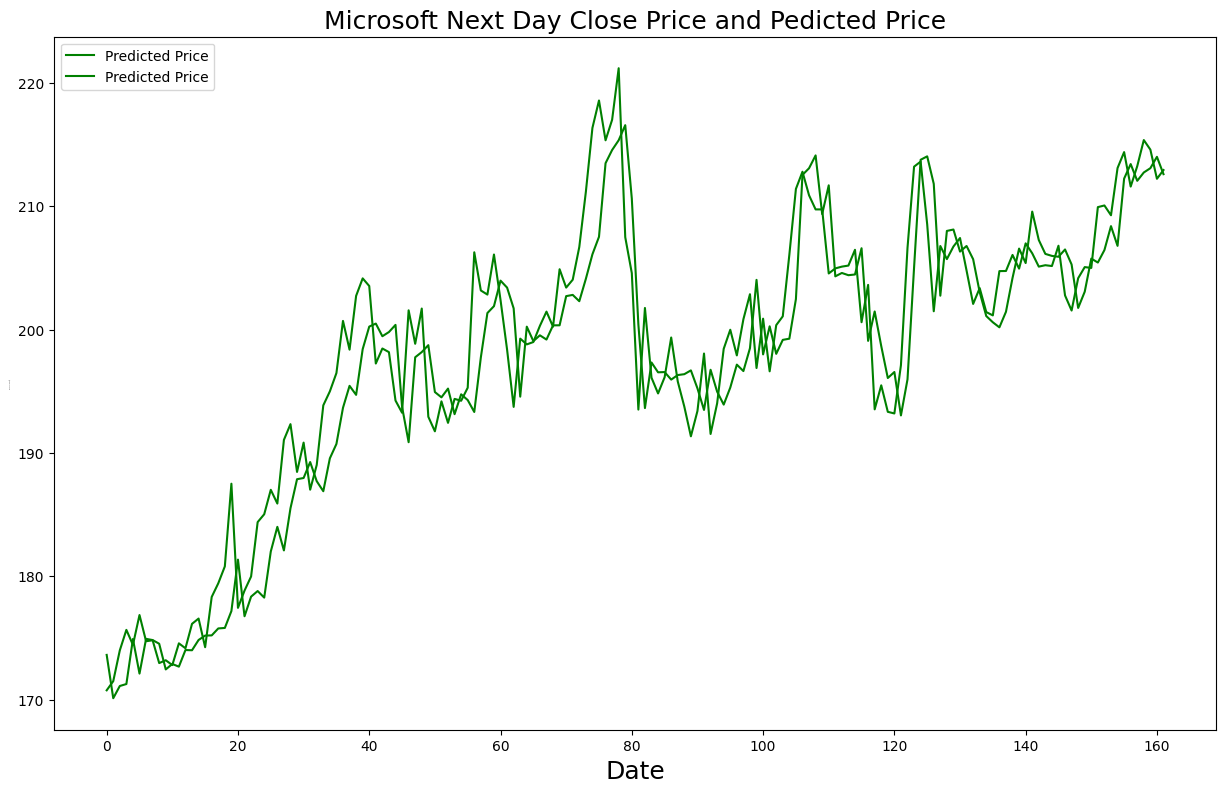

In [24]:
plt.figure(figsize= (15,9))
plt.title('Microsoft Next Day Close Price and Pedicted Price', fontsize  = 18)
plt.plot(df_TP['Target'], label="Predicted Price", color = 'green', alpha=1)
plt.plot(df_TP['Pred'],label="Predicted Price", color = 'green', alpha=1)
plt.xlabel('Date', fontsize = 18)
plt.legend(loc = "upper left")
plt.ylabel('Price in USD $', fontsize = 1)

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


sys.path.append(os.path.join(os.getcwd(), "files"))

from polymarket_integration import (
    PolymarketDataFetcher,
    create_market_sentiment_score,
    xgb_predict_enhanced,
    ensemble_prediction,
    print_comparison_metrics,
    plot_ensemble_comparison,
)

np.random.seed(42)

In [ ]:
def validate_with_polymarket_signal(
    data: pd.DataFrame,
    perc: float = 0.2,
    polymarket_weight: float = 0.3,
    sentiment_col: str = "market_sentiment",
):
    """Walk-forward validation using an explicit Polymarket sentiment column."""

    if sentiment_col not in data.columns:
        raise ValueError(f"Expected sentiment column '{sentiment_col}' in dataframe")

    arr = data.values
    n = int(len(arr) * (1 - perc))
    train, test = arr[:n], arr[n:]

  
    sent_idx = list(data.columns).index(sentiment_col)

    predictions_xgb = []
    predictions_ensemble = []
    actuals = []

    history = [x for x in train]

    for i in range(len(test)):
        X_test, y_test = test[i, :-1], test[i, -1]

     
        xgb_pred = xgb_predict_enhanced(history, X_test)
        predictions_xgb.append(xgb_pred)

       
        polymarket_signal = float(test[i, sent_idx])

        ensemble_pred = ensemble_prediction(
            xgb_pred,
            polymarket_signal,
            weights=(1 - polymarket_weight, polymarket_weight),
        )
        predictions_ensemble.append(ensemble_pred)

        actuals.append(y_test)
        history.append(test[i])

    from sklearn.metrics import mean_squared_error

    rmse_xgb = float(np.sqrt(mean_squared_error(actuals, predictions_xgb)))
    rmse_ensemble = float(np.sqrt(mean_squared_error(actuals, predictions_ensemble)))

    def mape(actual, pred):
        actual, pred = np.array(actual), np.array(pred)
        return float(np.mean(np.abs((actual - pred) / actual)) * 100)

    return {
        "rmse_xgb": rmse_xgb,
        "rmse_ensemble": rmse_ensemble,
        "mape_xgb": mape(actuals, predictions_xgb),
        "mape_ensemble": mape(actuals, predictions_ensemble),
        "actuals": actuals,
        "predictions_xgb": predictions_xgb,
        "predictions_ensemble": predictions_ensemble,
    }


PREDICTION MODEL COMPARISON

Metric               XGBoost         Ensemble        Improvement    
------------------------------------------------------------
RMSE                 0.0932          0.0903          +3.15%
MAPE (%)             8.89            8.60            +3.25%


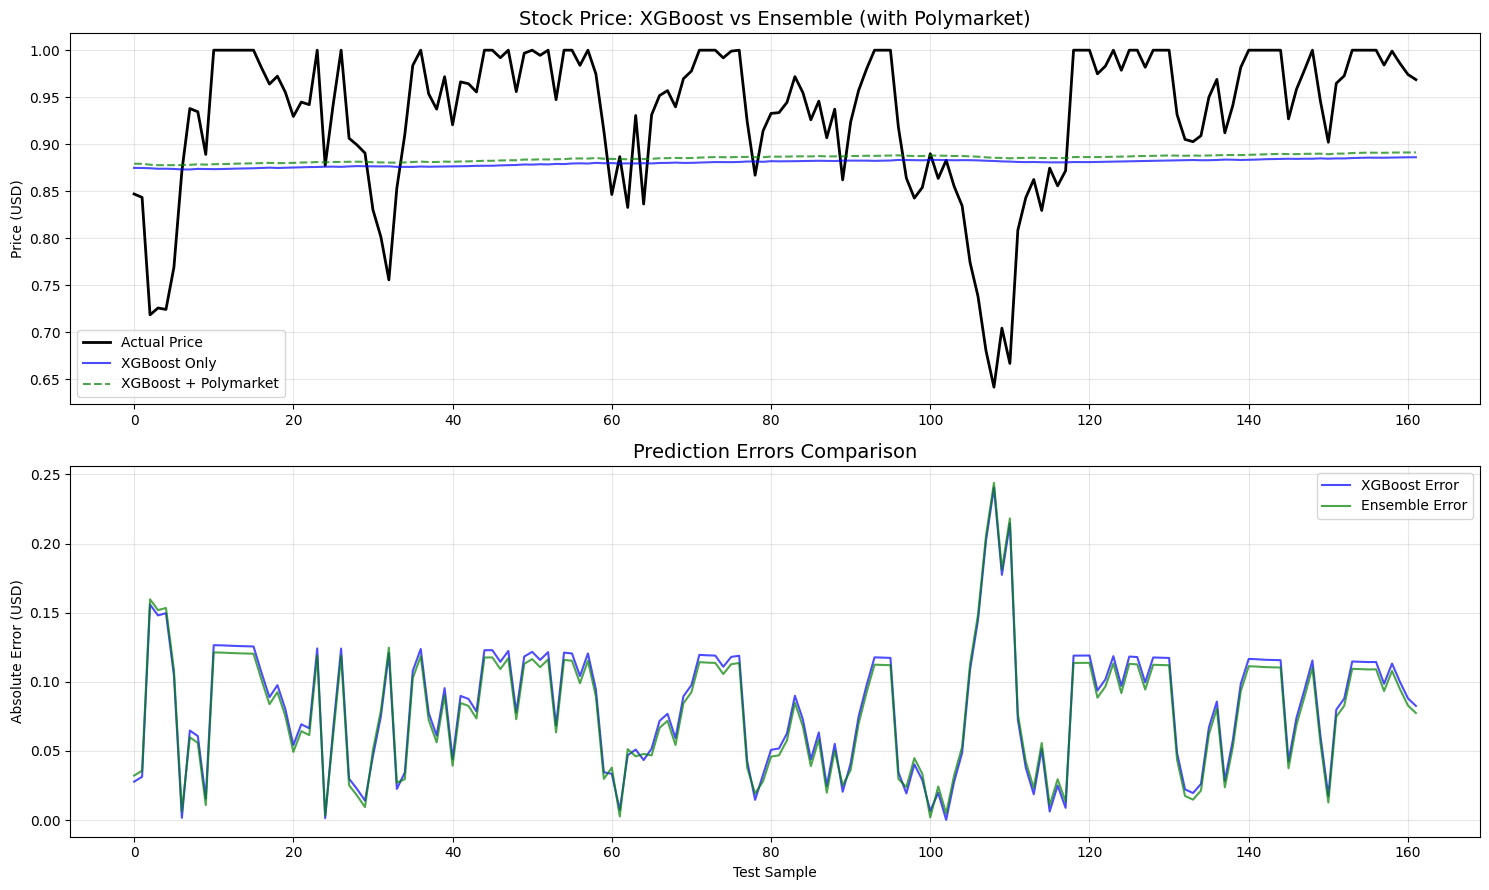

In [ ]:


def synthetic_polymarket_sentiment(n: int, drift: float = 0.00, sigma: float = 0.05):
    s = 0.0
    out = []
    for _ in range(n):
        s = float(np.clip(s + np.random.normal(drift, sigma), -1, 1))
        out.append(s)
    return out



df_poly = df.copy()
df_poly["market_sentiment"] = synthetic_polymarket_sentiment(len(df_poly), drift=0.01)

results_poly = validate_with_polymarket_signal(df_poly, perc=0.2, polymarket_weight=0.3)
print_comparison_metrics(results_poly)
plot_ensemble_comparison(results_poly)

Composite Polymarket sentiment (snapshot): +0.000

PREDICTION MODEL COMPARISON

Metric               XGBoost         Ensemble        Improvement    
------------------------------------------------------------
RMSE                 0.0528          0.0528          +0.00%
MAPE (%)             135.39          135.38          +0.00%


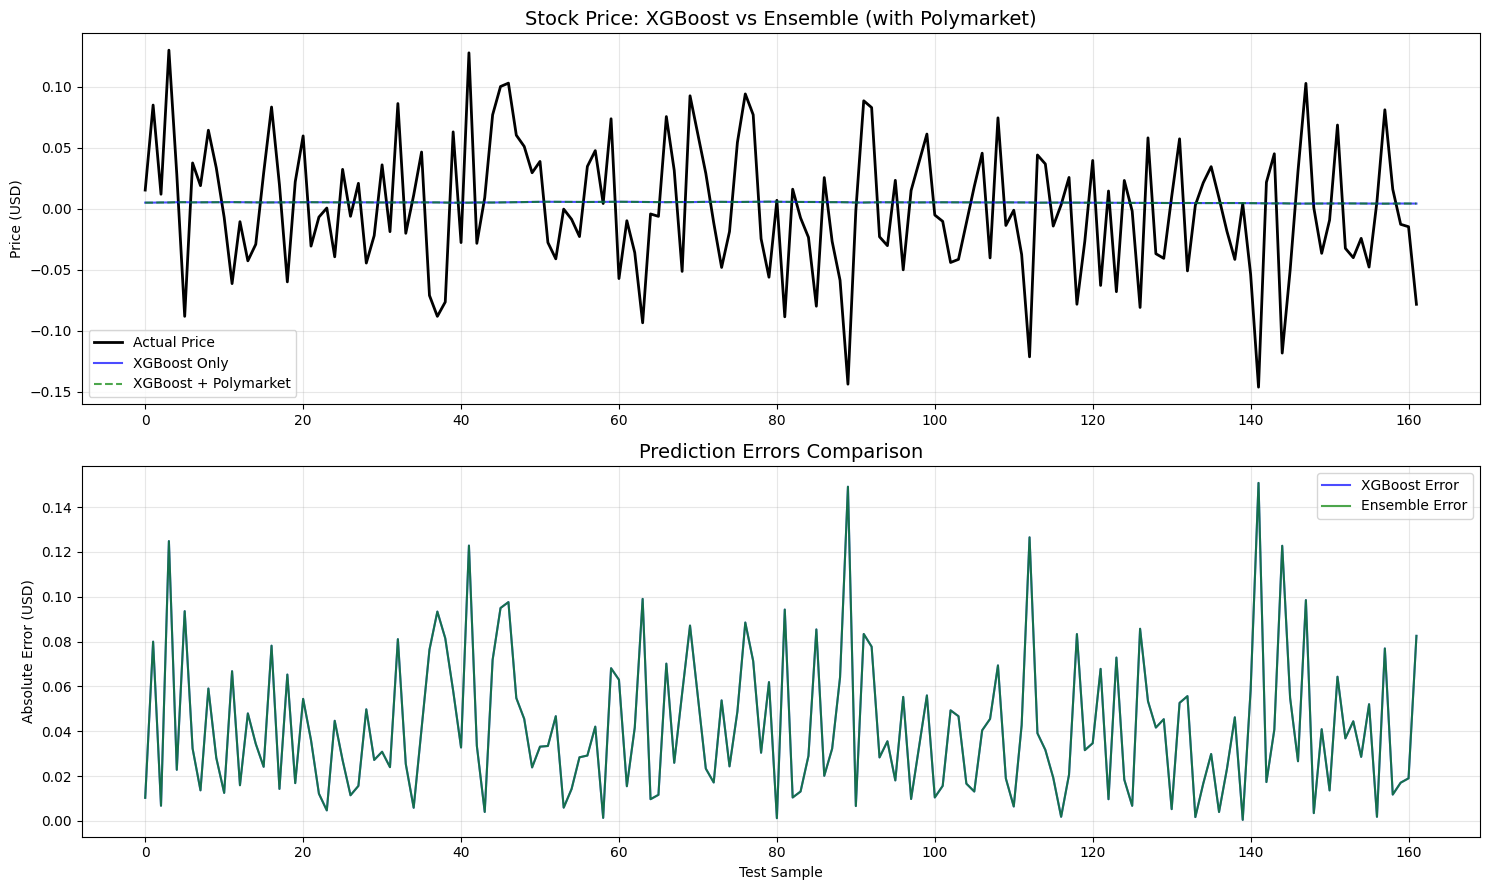

In [ ]:

fetcher = PolymarketDataFetcher()

search_terms = [
    "S&P 500",
    "technology stocks",
    "US inflation",
    "Federal Reserve",
]

def normalize_markets_response(resp):
    """Polymarket CLOB responses are typically a dict with a 'data' list."""
    if isinstance(resp, dict):
        return resp.get("data", [])
    if isinstance(resp, list):
        return resp
    return []

markets = []
for term in search_terms:
    resp = fetcher.get_markets(term, limit=3)
    markets.extend(normalize_markets_response(resp))

market_payloads = []
for m in markets[:10]:
    if not isinstance(m, dict):
        continue
    market_id = m.get("id") or m.get("market_id")
    if not market_id:
        continue
    payload = fetcher.get_market_prices(market_id)
    if payload:
        market_payloads.append(payload)

composite_sentiment = float(create_market_sentiment_score(market_payloads)) if market_payloads else 0.0
print(f"Composite Polymarket sentiment (snapshot): {composite_sentiment:+.3f}")

df_poly_live["market_sentiment"] = (
    composite_sentiment + np.random.normal(0, 0.05, size=len(df_poly_live))
).clip(-1, 1)

results_poly_live = validate_with_polymarket_signal(df_poly_live, perc=0.2, polymarket_weight=0.3)
print_comparison_metrics(results_poly_live)
plot_ensemble_comparison(results_poly_live)